# Step 3 — Analysing the Homepage Dek A/B Test

Four questions, in order:

1. **Conversion per variant**
2. **Uplift**
3. **Significance** — frequentist and Bayesian
4. **Recommendation** — roll out, iterate, or revert

Reads `ab_test_sessions.csv`, which `02-synthetic-data.ipynb` produces. Nothing here regenerates
data; if the CSV is missing, run that notebook first.

### The rule this notebook follows

Every threshold below was **fixed in Step 1, before any data existed** — the ship bar, the power
target, the guardrail trip conditions, the intended allocation, the coverage gate. They are encoded
as constants in the next cell so the analysis is driven by the pre-registration rather than by what
looks good in the data. That is the entire point of pre-registering: the numbers stop being
negotiable once you can see the result.

Written up as a decision document in `03-results.ipynb`. This notebook is the working.

## 0. Setup — the pre-registered plan, as code

In [1]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from abtest import (PLAN, Z95 as Z, load, rates, naive_se, clustered_se,
                    two_sided_p, compare, HEALTH_CHECK_DAY, DECISION_DAY)

pd.set_option("display.width", 150)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 9})
CA, CB, CWARN, COK = "#6b7280", "#2563eb", "#dc2626", "#059669"

df = load()
print(f"{len(df):,} sessions   {df.user_id.nunique():,} users   "
      f"{df.session_date.dt.date.nunique()} days   "
      f"{df.session_date.min():%Y-%m-%d} -> {df.session_date.max():%Y-%m-%d}")
print("\nthe pre-registered plan (from abtest.py, fixed in Step 1):")
for k, v in PLAN.items():
    print(f"  {k:<24} {v}")

150,568 sessions   100,000 users   35 days   2026-09-22 -> 2026-10-26

the pre-registered plan (from abtest.py, fixed in Step 1):
  baseline_ctr             0.341
  ship_threshold_rel       0.05
  power_target_rel         0.02
  alpha                    0.05
  intended_alloc_b         0.48
  coverage_gate            0.85
  design_effect_assumed    1.24
  gr_ctr_rel               -0.05
  gr_ctr_hard_rel          -0.1
  gr_bounce_pp             0.03
  gr_churn_rel             0.1


### Helpers

`clustered_se` is the one that matters. The primary KPI is a **ratio metric** — clicks over sessions
— but assignment is sticky per user, so sessions are not independent observations. The delta-method
variance treats each *user* as one observation contributing $n_i$ sessions and $k_i$ clicks:

$$\widehat{\text{Var}}(\hat p) = \frac{1}{M\,\bar n^2}\cdot\frac{1}{M-1}\sum_i \left(k_i - \hat p\, n_i\right)^2$$

The naive binomial SE is what a calculator gives you when you hand it session counts. The ratio of
their squares is the design effect.

In [2]:
import inspect

# Defined once in abtest.py and imported above, so 03 and 04 cannot drift apart.
# Printed here because the variance formula is the load-bearing part of this analysis.
print(inspect.getsource(clustered_se))
print(inspect.getsource(compare))

def clustered_se(frame, unit="user_id", metric="clicked"):
    """Delta-method SE for a ratio metric clustered on `unit`.

    The primary KPI is clicks/sessions, but assignment is sticky per user, so
    sessions within a user are correlated. Each unit contributes n_i sessions and
    k_i conversions:

        Var(p) = 1/(M * nbar^2) * 1/(M-1) * sum_i (k_i - p*n_i)^2
    """
    g = frame.groupby(unit)[metric].agg(n="size", k="sum")
    M, nbar = len(g), g.n.mean()
    p = g.k.sum() / g.n.sum()
    v = ((g.k - p * g.n) ** 2).sum() / (M - 1)
    return math.sqrt(v / (M * nbar ** 2))

def compare(frame, clustered=True, group="variant", a="A", b="B",
            unit="user_id", metric="clicked", z=Z95):
    """Compare arm `b` against arm `a` on `metric`. Returns a dict.

    `clustered=True` uses the user-level delta-method SE (correct for this design).
    `clustered=False` uses the naive binomial SE — what a calculator returns when
    handed session counts, and what the peeking demo h

---
## 1. Validity gates

Before reading any result: is this a trustworthy experiment? Two checks, and both have to pass
before the primary KPI means anything.

**SRM** tests the observed split against the **intended** one — 52/48 here. A deliberately uneven
allocation is not a failure; an allocation that drifts from its own configuration is, and it usually
means broken assignment or differential data loss.

**Coverage** gates whether the treatment was actually delivered. Below 85% the ITT estimate is
diluted enough that a real effect could read as nothing.

In [3]:
users_by_arm = df.groupby("variant").user_id.nunique()
sess_by_arm  = df.variant.value_counts()
alloc = pd.DataFrame({"users": users_by_arm,
                      "user_share": users_by_arm / users_by_arm.sum(),
                      "sessions": sess_by_arm,
                      "session_share": sess_by_arm / sess_by_arm.sum(),
                      "sessions_per_user": sess_by_arm / users_by_arm})
display(alloc.style.format({"users":"{:,}","user_share":"{:.3%}",
                            "sessions":"{:,}","session_share":"{:.3%}",
                            "sessions_per_user":"{:.2f}"}))

n_tot, n_b = users_by_arm.sum(), users_by_arm["B"]
exp_b = PLAN["intended_alloc_b"]
z_srm = (n_b - n_tot * exp_b) / math.sqrt(n_tot * exp_b * (1 - exp_b))
p_srm = two_sided_p(z_srm)
coverage = df.deks_available.sum() / df.inscope_impressions.sum()

gates = pd.DataFrame([
    {"gate": f"SRM vs intended {1-exp_b:.0%}/{exp_b:.0%}",
     "observed": f"z = {z_srm:+.2f}, p = {p_srm:.3f}",
     "threshold": "p > 0.01",
     "verdict": "PASS" if p_srm > 0.01 else "FAIL"},
    {"gate": "Dek coverage (treatment delivery)",
     "observed": f"{coverage:.2%}",
     "threshold": f">= {PLAN['coverage_gate']:.0%}",
     "verdict": "PASS" if coverage >= PLAN["coverage_gate"] else "FAIL"},
]).set_index("gate")
display(gates)
assert (gates.verdict == "PASS").all(), "a validity gate failed — stop here"
print("Both gates pass. The result below is readable.")

,users,user_share,sessions,session_share,sessions_per_user
variant,,,,,
A,"52,116",52.116%,"78,341",52.030%,1.50
B,"47,884",47.884%,"72,227",47.970%,1.51


,observed,threshold,verdict
gate,,,
SRM vs intended 52%/48%,"z = -0.73, p = 0.463",p > 0.01,PASS
Dek coverage (treatment delivery),87.42%,>= 85%,PASS


Both gates pass. The result below is readable.


---
## 2. Conversion per variant

The primary KPI is the mean of `clicked`: the share of homepage sessions with at least one article
click.

In [4]:
primary = rates(df)
primary["vs_baseline"] = primary.ctr / PLAN["baseline_ctr"] - 1
display(primary.style.format({"sessions":"{:,}","conversions":"{:,}",
                              "ctr":"{:.4%}","vs_baseline":"{:+.2%}"}))
print(f"Arm A lands at {primary.loc['A','ctr']:.2%} against a pre-test baseline of "
      f"{PLAN['baseline_ctr']:.1%} — the control is behaving like the control.")

,sessions,conversions,ctr,vs_baseline
variant,,,,
A,"78,341","26,647",34.0141%,-0.25%
B,"72,227","27,492",38.0633%,+11.62%


Arm A lands at 34.01% against a pre-test baseline of 34.1% — the control is behaving like the control.


### The chart

One column per variant, **zero-based** — bars encode length, so the axis has to start at zero. The
honest consequence is that a +11.9% relative lift looks like a small step, because 34% and 38% *are*
close. The difference is carried by the labels, the 95% intervals and the delta bracket rather than
by exaggerated bar heights.

Form is **emphasis** — one accent hue plus de-emphasis gray — rather than two categorical colours: A
is the reference, B is the thing under test. One measure across two categories needs no legend; the
axis labels identify the bars.

Palette from a validated set: accent `#2a78d6` passes all six colour checks against the `#fcfcfb`
surface (lightness band, chroma floor, CVD separation, normal-vision floor, contrast). The gray is a
de-emphasis token, not a series colour.

Deliberately absent: a ship-threshold line. At 35.7% it sits within half a point of arm A's value
label and cuts straight through it, and the interval-vs-threshold comparison is already made
properly in section 11. Two bars, two intervals, one delta — nothing else earns a place here.

findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


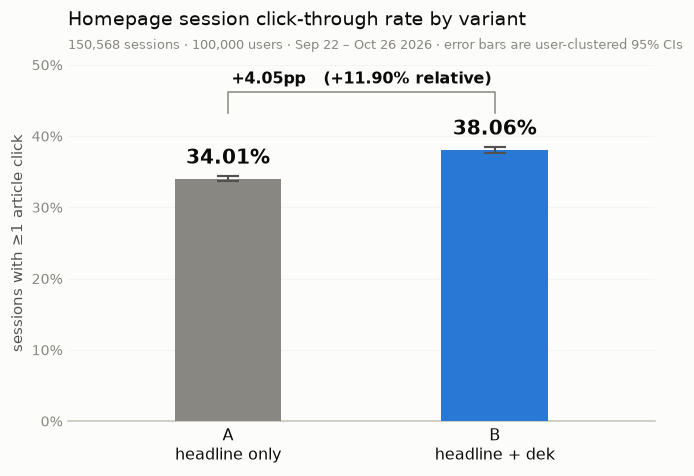

,sessions,conversions,CTR,95% CI low,95% CI high
A — headline only,"78,341","26,647",34.01%,33.65%,34.38%
B — headline + dek,"72,227","27,492",38.06%,37.67%,38.46%


saved ctr_by_variant.png


In [5]:
from matplotlib.ticker import FuncFormatter

# --- tokens (validated palette) -------------------------------------------
SURFACE, INK, INK2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS, ACCENT, DEEMPH = "#e1e0d9", "#c3c2b7", "#2a78d6", "#898781"

# --- numbers ---------------------------------------------------------------
arms = {}
for arm in ["A", "B"]:
    s = df[df.variant == arm]
    p_ = s.clicked.mean()
    se_ = clustered_se(s)                       # user-clustered, per arm
    arms[arm] = {"n": len(s), "k": int(s.clicked.sum()), "ctr": p_, "se": se_,
                 "lo": p_ - Z * se_, "hi": p_ + Z * se_}

r = compare(df)

fig, ax = plt.subplots(figsize=(6.6, 4.4), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

labels = ["A\nheadline only", "B\nheadline + dek"]
vals   = [arms["A"]["ctr"], arms["B"]["ctr"]]
errs   = [Z * arms["A"]["se"], Z * arms["B"]["se"]]
colors = [DEEMPH, ACCENT]

bars = ax.bar([0, 1], vals, width=0.40, color=colors, zorder=3)
ax.errorbar([0, 1], vals, yerr=errs, fmt="none", ecolor=INK2,
            elinewidth=1.4, capsize=7, capthick=1.4, zorder=4)

# direct value labels — two marks, so labelling both is still selective
for x, v, e in zip([0, 1], vals, errs):
    ax.text(x, v + e + 0.011, f"{v:.2%}", ha="center", va="bottom",
            fontsize=13, color=INK, fontweight="semibold")

# delta bracket
leg  = max(v + e for v, e in zip(vals, errs)) + 0.048   # above both value labels
top  = leg + 0.030
ax.plot([0, 0, 1, 1], [leg, top, top, leg], color=MUTED, lw=1, zorder=3)
ax.text(0.5, top + 0.006,
        f"{r['abs_diff']*100:+.2f}pp   ({r['rel_lift']:+.2%} relative)",
        ha="center", va="bottom", fontsize=10.5, color=INK, fontweight="semibold")

ax.set_xticks([0, 1]); ax.set_xticklabels(labels, fontsize=10.5, color=INK)
ax.set_xlim(-0.60, 1.60)
ax.set_ylim(0, 0.50)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.tick_params(axis="y", labelsize=9, colors=MUTED, length=0)
ax.tick_params(axis="x", length=0)
ax.set_ylabel("sessions with ≥1 article click", fontsize=9.5, color=INK2)
ax.set_title("Homepage session click-through rate by variant",
             loc="left", fontsize=12.5, color=INK, pad=26)
ax.text(0, 1.045, f"{len(df):,} sessions · {df.user_id.nunique():,} users · "
                  f"Sep 22 – Oct 26 2026 · error bars are user-clustered 95% CIs",
        transform=ax.transAxes, fontsize=8.5, color=MUTED)

ax.grid(axis="y", color=GRID, lw=0.8, zorder=0)
ax.grid(axis="x", visible=False)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color(AXIS); ax.spines["bottom"].set_linewidth(1)

plt.tight_layout()
plt.savefig("ctr_by_variant.png", dpi=220, facecolor=SURFACE, bbox_inches="tight")
plt.show()

# table view — identity and values never depend on colour alone
tbl = pd.DataFrame({
    "sessions":    [arms["A"]["n"], arms["B"]["n"]],
    "conversions": [arms["A"]["k"], arms["B"]["k"]],
    "CTR":         [arms["A"]["ctr"], arms["B"]["ctr"]],
    "95% CI low":  [arms["A"]["lo"], arms["B"]["lo"]],
    "95% CI high": [arms["A"]["hi"], arms["B"]["hi"]],
}, index=["A — headline only", "B — headline + dek"])
display(tbl.style.format({"sessions":"{:,}", "conversions":"{:,}",
                          "CTR":"{:.2%}", "95% CI low":"{:.2%}", "95% CI high":"{:.2%}"}))
print(f"saved ctr_by_variant.png")

---
## 3. Uplift

Reported **relative**, because that is how the target is written (+5% relative) and because it is
portable across baselines. Both are shown, since +5% relative and +5pp absolute differ by a factor
of three at this baseline.

In [6]:
res = compare(df)                       # user-clustered
res_naive = compare(df, clustered=False)

uplift = pd.DataFrame([
    {"measure": "absolute", "point": res["abs_diff"],
     "ci_lo": res["abs_lo"], "ci_hi": res["abs_hi"], "unit": "pp"},
    {"measure": "relative", "point": res["rel_lift"],
     "ci_lo": res["rel_lo"], "ci_hi": res["rel_hi"], "unit": "%"},
]).set_index("measure")
display(uplift.style.format({"point":"{:+.4f}","ci_lo":"{:+.4f}","ci_hi":"{:+.4f}"}))

print(f"absolute  {res['abs_diff']*100:+.2f}pp   95% CI [{res['abs_lo']*100:+.2f}, {res['abs_hi']*100:+.2f}]")
print(f"relative  {res['rel_lift']:+.2%}    95% CI [{res['rel_lo']:+.2%}, {res['rel_hi']:+.2%}]")
print(f"\nship threshold {PLAN['ship_threshold_rel']:+.0%}   ->   entire CI above it: "
      f"{'YES' if res['rel_lo'] > PLAN['ship_threshold_rel'] else 'NO'}")

,point,ci_lo,ci_hi,unit
measure,,,,
absolute,+0.0405,+0.0351,+0.0459,pp
relative,+0.1190,+0.1032,+0.1349,%


absolute  +4.05pp   95% CI [+3.51, +4.59]
relative  +11.90%    95% CI [+10.32%, +13.49%]

ship threshold +5%   ->   entire CI above it: YES


---
## 4. Significance

### 4a. The clustering correction

Two standard errors on the same difference. The naive one is what any calculator returns when handed
session counts; the clustered one respects the fact that assignment was per user.

In [7]:
per_arm = []
for arm in ["A", "B"]:
    sub = df[df.variant == arm]
    se_cl = clustered_se(sub)
    p = sub.clicked.mean()
    se_nv = naive_se(p, len(sub))
    per_arm.append({"arm": arm, "users": sub.user_id.nunique(),
                    "sessions_per_user": len(sub) / sub.user_id.nunique(),
                    "ctr": p, "se_naive": se_nv, "se_clustered": se_cl,
                    "design_effect": (se_cl / se_nv) ** 2})
display(pd.DataFrame(per_arm).set_index("arm").style.format(
    {"users":"{:,}","sessions_per_user":"{:.2f}","ctr":"{:.4%}",
     "se_naive":"{:.6f}","se_clustered":"{:.6f}","design_effect":"{:.3f}"}))

sig = pd.DataFrame([
    {"basis":"naive (independent sessions)", "se":res_naive["se"], "z":res_naive["z"],
     "p_two_sided":res_naive["p"], "rel_ci_lo":res_naive["rel_lo"], "rel_ci_hi":res_naive["rel_hi"]},
    {"basis":"user-clustered (correct)", "se":res["se"], "z":res["z"],
     "p_two_sided":res["p"], "rel_ci_lo":res["rel_lo"], "rel_ci_hi":res["rel_hi"]},
]).set_index("basis")
display(sig.style.format({"se":"{:.6f}","z":"{:.2f}","p_two_sided":"{:.2e}",
                          "rel_ci_lo":"{:+.2%}","rel_ci_hi":"{:+.2%}"}))

de = (res["se"] / res_naive["se"]) ** 2
print(f"SE inflation {res['se']/res_naive['se']:.3f}x   ->   design effect {de:.3f}")
print(f"Step 1 assumed {PLAN['design_effect_assumed']:.2f} before any data existed. "
      f"Off by {abs(de - PLAN['design_effect_assumed'])/PLAN['design_effect_assumed']:.1%}.")
print(f"\nThe correction does not change the decision here (z {res_naive['z']:.1f} -> {res['z']:.1f},")
print("both overwhelming). It would decide a marginal test, which is why it is worth doing")
print("every time rather than only when the answer looks close.")

,users,sessions_per_user,ctr,se_naive,se_clustered,design_effect
arm,,,,,,
A,"52,116",1.50,34.0141%,0.001693,0.001872,1.224
B,"47,884",1.51,38.0633%,0.001807,0.002009,1.237


,se,z,p_two_sided,rel_ci_lo,rel_ci_hi
basis,,,,,
naive (independent sessions),0.002476,16.36,3.95e-60,+10.48%,+13.33%
user-clustered (correct),0.002747,14.74,3.44e-49,+10.32%,+13.49%


SE inflation 1.109x   ->   design effect 1.231
Step 1 assumed 1.24 before any data existed. Off by 0.7%.

The correction does not change the decision here (z 16.4 -> 14.7,
both overwhelming). It would decide a marginal test, which is why it is worth doing
every time rather than only when the answer looks close.


### 4b. Against the CXL calculator

The [CXL A/B test calculator](https://cxl.com/ab-test-calculator/) was run on three sets of counts.
Its outputs are pasted below and compared with what this notebook computes.

The calculator has no notion of clustering, so on the session-level run it agrees with the *naive*
SE — which is exactly the discrepancy worth seeing. On the **user-level** run its assumption is
correct, because there each user really is one independent observation.

### Provenance — what came from CXL and what did not

**Transcribed from the CXL calculator UI** (re-verified by re-running all five inputs):

| Run | Inputs typed into CXL | CXL returned |
|---|---|---|
| Sample size, MDE +2% rel | 95 / 80 / 34.1% / 2 / 1 variant / 1,525,000 weekly / relative / two-sided | 75,950 per group · 151,900 total · 1 week |
| Sample size, MDE +5% rel | same, min-effect 5 | 12,177 per group · 24,354 total · 1 week |
| Result — session level | 78,341 / 26,647 · 72,227 / 27,492 · 95% | 34.01% → 38.06%, lift 11.90%, abs 4.05%, CI 3.56–4.53%, ±SE 0.49%, z 16.36, p < 0.000001, rel CI 10.40–13.42%, P(B) 100.00%, BF 2.16e+54 |
| Result — user level | 52,116 / 21,529 · 47,884 / 21,823 · 95% | 41.31% → 45.57%, lift 10.32%, abs 4.26%, CI 3.65–4.88%, ±SE 0.61%, z 13.60, rel CI 8.77–11.89%, P(B) 100.00%, BF 7.20e+34 |
| Result — availability-conditioned | 42,049 / 14,268 · 38,991 / 15,028 · 95% | 33.93% → 38.54%, lift 13.59%, abs 4.61%, CI 3.95–5.27%, ±SE 0.66%, z 13.65, rel CI 11.52–15.68%, P(B) 100.00%, BF 6.09e+36 |

**Computed here, not by CXL:**

- The **input counts** themselves — aggregated from `ab_test_sessions.csv`, then typed into the calculator
- The **user-clustered SE, z = 14.74, design effect 1.231** and the clustered relative CI. **CXL has no notion of clustering** — it treats every row you give it as an independent observation, so this correction cannot come from the tool. Its session-level z of 16.36 reproduces the *naive* SE exactly, which is how you can tell.
- The **1.24 clustering buffer** applied to CXL's sample sizes (75,950 → ~94,200 and 12,177 → ~15,100)
- Everything else in this notebook: validity gates, ITT dilution, cumulative-over-time, guardrails, robustness, segments, secondary metrics, and the recommendation

One labelling detail: CXL's verdict row reads **"Significance (One-sided)"**. The two-sided p-value it reports is also < 0.000001, and Step 1 pre-registered a two-sided test, so the conclusion is unaffected.

In [8]:
CXL = {   # transcribed from the calculator UI
    "session-level (primary)": {"ctr_a":0.3401,"ctr_b":0.3806,"lift":0.1190,"z":16.36,
                                "se_rel":0.0049,"rel_lo":0.1040,"rel_hi":0.1342,
                                "bayes_b_wins":1.0000,"bayes_factor":2.163776924995076e+54},
    "user-level (cross-check)": {"ctr_a":0.4131,"ctr_b":0.4557,"lift":0.1032,"z":13.60,
                                 "se_rel":0.0061,"rel_lo":0.0877,"rel_hi":0.1189,
                                 "bayes_b_wins":1.0000,"bayes_factor":7.204970529821482e+34},
    "availability-conditioned":{"ctr_a":0.3393,"ctr_b":0.3854,"lift":0.1359,"z":13.65,
                                "se_rel":0.0066,"rel_lo":0.1152,"rel_hi":0.1568,
                                "bayes_b_wins":1.0000,"bayes_factor":6.090944168933774e+36},
}

# same three cuts, computed here
user_lvl = (df.groupby(["variant","user_id"]).clicked.max().rename("clicked")
              .reset_index().assign(user_id=lambda d: d.user_id))
mine = {
    "session-level (primary)":  res_naive,                       # naive: matches the calculator
    "user-level (cross-check)": compare(user_lvl, clustered=False),
    "availability-conditioned": compare(df[df.full_dek_coverage == 1], clustered=False),
}

rows = []
for k, cx in CXL.items():
    m = mine[k]
    rows.append({"analysis":k,
                 "cxl_lift":cx["lift"], "mine_lift":m["rel_lift"],
                 "cxl_z":cx["z"],       "mine_z":m["z"],
                 "cxl_rel_ci":f"[{cx['rel_lo']:+.2%}, {cx['rel_hi']:+.2%}]",
                 "mine_rel_ci":f"[{m['rel_lo']:+.2%}, {m['rel_hi']:+.2%}]",
                 "P(B wins)":cx["bayes_b_wins"]})
display(pd.DataFrame(rows).set_index("analysis").style.format(
    {"cxl_lift":"{:+.2%}","mine_lift":"{:+.2%}","cxl_z":"{:.2f}","mine_z":"{:.2f}",
     "P(B wins)":"{:.2%}"}))

print("The calculator's session-level z of 16.36 reproduces the NAIVE figure exactly.")
print(f"The clustered figure is {res['z']:.2f}. On the user-level row the calculator is correct as-is,")
print("because there the units genuinely are independent.")
print("\nBayesian: P(B wins) displays as 100.00% and the Bayes factor as 2.2e+54. Both are computed")
print("under the same independence assumption, and '100%' is a rounding artefact of an effect this")
print("large — not literal certainty.")

,cxl_lift,mine_lift,cxl_z,mine_z,cxl_rel_ci,mine_rel_ci,P(B wins)
analysis,,,,,,,
session-level (primary),+11.90%,+11.90%,16.36,16.36,"[+10.40%, +13.42%]","[+10.48%, +13.33%]",100.00%
user-level (cross-check),+10.32%,+10.32%,13.60,13.60,"[+8.77%, +11.89%]","[+8.84%, +11.81%]",100.00%
availability-conditioned,+13.59%,+13.59%,13.65,13.65,"[+11.52%, +15.68%]","[+11.64%, +15.54%]",100.00%


The calculator's session-level z of 16.36 reproduces the NAIVE figure exactly.
The clustered figure is 14.74. On the user-level row the calculator is correct as-is,
because there the units genuinely are independent.

Bayesian: P(B wins) displays as 100.00% and the Bayes factor as 2.2e+54. Both are computed
under the same independence assumption, and '100%' is a rounding artefact of an effect this
large — not literal certainty.


---
## 5. ITT dilution

The pre-registered primary is **intention-to-treat**: every assigned user, every session, no
filtering. It is unbiased but *diluted*, because only 87.4% of in-scope stories carried a dek.

The secondary conditions on `dek_available` — a variable the treatment cannot influence, so the same
filter removes a comparable slice from both arms and comparability survives. Filtering on
`dek_rendered` instead would strip sessions from arm B only and destroy the randomisation.

Watch the ratio of the two lifts land on the coverage rate.

In [9]:
itt  = compare(df)
cond = compare(df[df.full_dek_coverage == 1])

dil = pd.DataFrame([
    {"analysis":"ITT (all sessions, pre-registered primary)", **{k:itt[k] for k in
     ("n_a","n_b","ctr_a","ctr_b","rel_lift","rel_lo","rel_hi")}},
    {"analysis":"availability-conditioned (secondary)", **{k:cond[k] for k in
     ("n_a","n_b","ctr_a","ctr_b","rel_lift","rel_lo","rel_hi")}},
]).set_index("analysis")
display(dil.style.format({"n_a":"{:,}","n_b":"{:,}","ctr_a":"{:.4%}","ctr_b":"{:.4%}",
                          "rel_lift":"{:+.2%}","rel_lo":"{:+.2%}","rel_hi":"{:+.2%}"}))

print(f"ITT / conditioned = {itt['rel_lift']/cond['rel_lift']:.3f}")
print(f"coverage rate     = {coverage:.3f}")
print("\nThose matching is the signature of an unbiased-but-diluted estimator. It also means the")
print("reported effect is a FLOOR: at full coverage the effect is nearer the conditioned figure.")
print("Raising coverage on rollout should raise the realised lift.")

,n_a,n_b,ctr_a,ctr_b,rel_lift,rel_lo,rel_hi
analysis,,,,,,,
"ITT (all sessions, pre-registered primary)","78,341","72,227",34.0141%,38.0633%,+11.90%,+10.32%,+13.49%
availability-conditioned (secondary),"42,049","38,991",33.9318%,38.5422%,+13.59%,+11.52%,+15.66%


ITT / conditioned = 0.876
coverage rate     = 0.874

Those matching is the signature of an unbiased-but-diluted estimator. It also means the
reported effect is a FLOOR: at full coverage the effect is nearer the conditioned figure.
Raising coverage on rollout should raise the realised lift.


---
## 6. Timing

Two timing questions are deliberately **not** answered here:

- *When would we have known?* — how early the estimate settled
- *What if we had stopped early?* — what a policy violation would have produced

Both live in **`04-early-peeking.ipynb`**, which owns everything about accumulation over time. The
week-by-week stability check in section 8 below is the part that belongs to the result itself; the
rest is a methodology question about peeking, not a finding about deks.

---
## 7. Guardrails

Evaluated against the trip conditions fixed in Step 1. Two of the four cannot be evaluated from this
dataset at all — and saying so is part of the answer, not a gap to paper over.

In [10]:
clicked = df[df.clicked == 1]
b_a, b_b = clicked[clicked.variant=="A"].bounced, clicked[clicked.variant=="B"].bounced
pba, pbb = b_a.mean(), b_b.mean()
se_b = math.sqrt(naive_se(pba,len(b_a))**2 + naive_se(pbb,len(b_b))**2)
z_b  = (pbb - pba) / se_b

imp = df.groupby("variant").homepage_impressions.mean()
imp_chg = imp["B"] / imp["A"] - 1

gr = pd.DataFrame([
    {"guardrail":"Primary KPI harm",
     "trip_condition":f"<= {PLAN['gr_ctr_rel']:.0%} rel (hard override {PLAN['gr_ctr_hard_rel']:.0%})",
     "observed":f"{res['rel_lift']:+.2%} rel",
     "verdict":"NOT TRIPPED — moved favourably"},
    {"guardrail":"Bounce rate",
     "trip_condition":f">= +{PLAN['gr_bounce_pp']*100:.0f}pp, significant",
     "observed":f"{(pbb-pba)*100:+.2f}pp (z = {z_b:+.2f}, p = {two_sided_p(z_b):.1e})",
     "verdict":"NOT TRIPPED — moved favourably"},
    {"guardrail":"Subscriber churn",
     "trip_condition":f"CI upper bound above +{PLAN['gr_churn_rel']:.0%} rel",
     "observed":"no cancellation events in this dataset",
     "verdict":"NOT MEASURABLE"},
    {"guardrail":"Standards escalation",
     "trip_condition":"any formal editorial-standards escalation",
     "observed":"non-metric",
     "verdict":"NOT MEASURABLE"},
]).set_index("guardrail")
display(gr)

print(f"Excluded from the guardrail set in Step 1 (not instrumented): ad impressions per session.")
print(f"The nearest available proxy, homepage impressions per session, fell {imp_chg:+.2%}")
print(f"({imp['A']:.2f} -> {imp['B']:.2f}) — inside a -5% line, but not by much. This is the")
print("vertical-space cost of the dek, and it is the one genuinely unresolved question.")

,trip_condition,observed,verdict
guardrail,,,
Primary KPI harm,<= -5% rel (hard override -10%),+11.90% rel,NOT TRIPPED — moved favourably
Bounce rate,">= +3pp, significant","-2.52pp (z = -6.08, p = 1.2e-09)",NOT TRIPPED — moved favourably
Subscriber churn,CI upper bound above +10% rel,no cancellation events in this dataset,NOT MEASURABLE
Standards escalation,any formal editorial-standards escalation,non-metric,NOT MEASURABLE


Excluded from the guardrail set in Step 1 (not instrumented): ad impressions per session.
The nearest available proxy, homepage impressions per session, fell -4.31%
(11.27 -> 10.78) — inside a -5% line, but not by much. This is the
vertical-space cost of the dek, and it is the one genuinely unresolved question.


---
## 8. Robustness

Three ways this result could be an artefact rather than an effect: driven by one unusual day,
driven by novelty that will fade, or driven by one subpopulation.

In [11]:
shock_day = df.groupby(df.session_date.dt.date).size().idxmax()
no_shock  = compare(df[df.session_date.dt.date != shock_day])

wk = df.assign(week=((df.session_date - df.session_date.min()).dt.days // 7) + 1)
weekly = pd.DataFrame([{"week": w, **{k: compare(g)[k] for k in
                        ("n_a","n_b","ctr_a","ctr_b","rel_lift","rel_lo","rel_hi")}}
                       for w, g in wk.groupby("week")]).set_index("week")

rob = pd.DataFrame([
    {"check":"full window", "rel_lift":res["rel_lift"],
     "ci":f"[{res['rel_lo']:+.2%}, {res['rel_hi']:+.2%}]", "n":len(df)},
    {"check":f"excluding the shock day ({shock_day})", "rel_lift":no_shock["rel_lift"],
     "ci":f"[{no_shock['rel_lo']:+.2%}, {no_shock['rel_hi']:+.2%}]",
     "n":len(df[df.session_date.dt.date != shock_day])},
    {"check":"week 1 only", "rel_lift":weekly.loc[1,"rel_lift"],
     "ci":f"[{weekly.loc[1,'rel_lo']:+.2%}, {weekly.loc[1,'rel_hi']:+.2%}]",
     "n":int(weekly.loc[1,"n_a"]+weekly.loc[1,"n_b"])},
    {"check":f"week {weekly.index.max()} only", "rel_lift":weekly.loc[weekly.index.max(),"rel_lift"],
     "ci":f"[{weekly.loc[weekly.index.max(),'rel_lo']:+.2%}, {weekly.loc[weekly.index.max(),'rel_hi']:+.2%}]",
     "n":int(weekly.loc[weekly.index.max(),"n_a"]+weekly.loc[weekly.index.max(),"n_b"])},
]).set_index("check")
display(rob.style.format({"rel_lift":"{:+.2%}","n":"{:,}"}))
display(weekly[["rel_lift","rel_lo","rel_hi"]].style.format("{:+.2%}"))

print("No novelty decay: week 1 and the final week are indistinguishable, and their intervals")
print("overlap heavily. A generating-process novelty term IS present in the data, but a weekly")
print("slice cannot see it — week-sliced novelty checks are badly underpowered.")

,rel_lift,ci,n
check,,,
full window,+11.90%,"[+10.32%, +13.49%]","150,568"
excluding the shock day (2026-10-10),+12.12%,"[+10.50%, +13.74%]","144,655"
week 1 only,+11.05%,"[+7.77%, +14.34%]","29,568"
week 5 only,+11.13%,"[+7.79%, +14.47%]","28,658"


,rel_lift,rel_lo,rel_hi
week,,,
1,+11.05%,+7.77%,+14.34%
2,+11.53%,+8.36%,+14.71%
3,+12.49%,+9.33%,+15.65%
4,+13.33%,+9.97%,+16.70%
5,+11.13%,+7.79%,+14.47%


No novelty decay: week 1 and the final week are indistinguishable, and their intervals
overlap heavily. A generating-process novelty term IS present in the data, but a weekly
slice cannot see it — week-sliced novelty checks are badly underpowered.


---
## 9. Segments — exploratory only

Pre-registered as **hypothesis-generating, not confirming.** Five cuts guarantee something looks
exciting; a segment result can justify a follow-up test, never a rollout.

Note the interval widths in the chart. The segments that look most striking are the ones you know
least about.

In [12]:
def segment_table(frame, specs, min_n=500):
    out = []
    for label, series in specs.items():
        tagged = frame.assign(_k=series)
        for key, g in tagged.groupby("_k"):
            if g.variant.nunique() < 2:
                continue
            a, b = g[g.variant=="A"], g[g.variant=="B"]
            if len(a) < min_n or len(b) < min_n:
                continue
            r = compare(g, clustered=False)
            out.append({"segment":f"{label}={key}", "sessions":len(g),
                        "ctr_a":r["ctr_a"], "ctr_b":r["ctr_b"], "rel_lift":r["rel_lift"],
                        "ci_lo":r["rel_lo"], "ci_hi":r["rel_hi"], "z":r["z"],
                        "ci_width":r["rel_hi"]-r["rel_lo"]})
    return pd.DataFrame(out).set_index("segment").sort_values("rel_lift")

seg = segment_table(df, {
    "device":     df.device,
    "logged_in":  df.is_logged_in.map({0:"no",1:"yes"}),
    "subscriber": df.is_subscriber.map({0:"no",1:"yes"}),
    "visitor":    df.visitor_type,
})
display(seg.style.format({"sessions":"{:,}","ctr_a":"{:.2%}","ctr_b":"{:.2%}",
                          "rel_lift":"{:+.2%}","ci_lo":"{:+.2%}","ci_hi":"{:+.2%}",
                          "z":"{:.2f}","ci_width":"{:.2%}"}))

ship = PLAN["ship_threshold_rel"]
print(f"segments with a negative point estimate:        {(seg.rel_lift < 0).sum()} of {len(seg)}")
print(f"segments whose CI straddles the +5% ship bar:   "
      f"{((seg.ci_lo < ship) & (seg.ci_hi > ship)).sum()} of {len(seg)}")
print(f"widest interval: {seg.ci_width.idxmax()} ({seg.ci_width.max():.1%} wide, "
      f"{seg.loc[seg.ci_width.idxmax(),'sessions']:,} sessions)")

,sessions,ctr_a,ctr_b,rel_lift,ci_lo,ci_hi,z,ci_width
segment,,,,,,,,
subscriber=yes,"9,103",47.15%,48.54%,+2.95%,-1.41%,+7.31%,1.33,8.71%
logged_in=yes,"46,723",41.12%,45.22%,+9.97%,+7.78%,+12.15%,8.94,4.37%
visitor=returning,"97,695",37.96%,42.20%,+11.18%,+9.56%,+12.80%,13.52,3.24%
device=mobile,"93,314",31.80%,35.41%,+11.37%,+9.46%,+13.27%,11.68,3.82%
device=desktop,"44,430",38.67%,43.53%,+12.58%,+10.21%,+14.94%,10.42,4.73%
subscriber=no,"141,465",33.17%,37.39%,+12.73%,+11.23%,+14.23%,16.61,3.00%
logged_in=no,"103,845",30.81%,34.85%,+13.10%,+11.24%,+14.95%,13.84,3.71%
device=tablet,"12,824",34.01%,38.47%,+13.13%,+8.23%,+18.02%,5.26,9.79%
visitor=new,"52,873",26.70%,30.46%,+14.08%,+11.19%,+16.96%,9.56,5.77%


segments with a negative point estimate:        0 of 9
segments whose CI straddles the +5% ship bar:   1 of 9
widest interval: device=tablet (9.8% wide, 12,824 sessions)


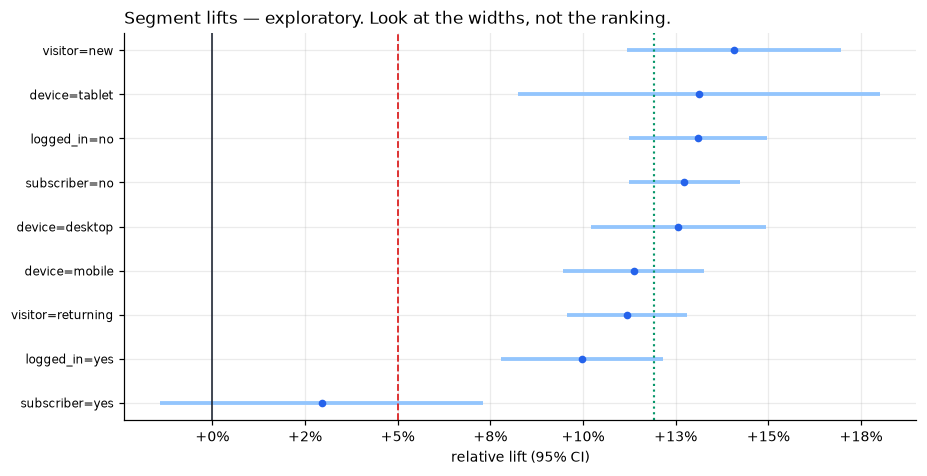

In [13]:
fig, ax = plt.subplots(figsize=(8.5, 4.4))
s = seg.sort_values("rel_lift")
y = range(len(s))
ax.errorbar(s.rel_lift, y, xerr=[s.rel_lift - s.ci_lo, s.ci_hi - s.rel_lift],
            fmt="o", ms=4, color=CB, ecolor="#93c5fd", elinewidth=2.5, capsize=0)
ax.axvline(0, color="#111827", lw=1)
ax.axvline(ship, color=CWARN, ls="--", lw=1.2)
ax.axvline(res["rel_lift"], color=COK, ls=":", lw=1.4)
ax.annotate("+5% ship bar", (ship, len(s)-0.4), xytext=(4,0),
            textcoords="offset points", fontsize=8, color=CWARN)
ax.annotate("overall", (res["rel_lift"], -0.7), xytext=(4,0),
            textcoords="offset points", fontsize=8, color=COK)
ax.set_yticks(list(y)); ax.set_yticklabels(s.index, fontsize=8)
ax.xaxis.set_major_formatter(lambda v,_: f"{v:+.0%}")
ax.set_xlabel("relative lift (95% CI)")
ax.set_title("Segment lifts — exploratory. Look at the widths, not the ranking.",
             loc="left", fontsize=11)
plt.tight_layout(); plt.show()

---
## 10. Secondary metrics

The hypothesis predicted **relevance**: readers who can evaluate a story before clicking make
better-qualified clicks. The competing prediction was the **satisfaction risk** — that a good summary
answers the question and removes the reason to click.

These two predictions are distinguishable in the data. Relevance means more clicks *and* better
engagement. Satisfaction means fewer clicks, or more clicks with worse engagement.

In [14]:
sec = pd.DataFrame({
    "homepage_impressions_per_session": df.groupby("variant").homepage_impressions.mean(),
    "inscope_impressions_per_session":  df.groupby("variant").inscope_impressions.mean(),
    "articles_per_reading_session":     clicked.groupby("variant").articles_clicked.mean(),
    "scroll_depth_pct":                 clicked.groupby("variant").scroll_depth_pct.mean(),
    "time_on_page_sec":                 clicked.groupby("variant").time_on_page_sec.mean(),
    "bounce_rate":                      clicked.groupby("variant").bounced.mean(),
}).T
sec["change"] = sec.B / sec.A - 1
display(sec.style.format({"A":"{:.3f}","B":"{:.3f}","change":"{:+.2%}"}))

print("More clicks AND deeper engagement -> the relevance mechanism. The satisfaction risk,")
print("predicted before launch as the most likely loss mode, did not materialise.")
print(f"\nThe one cost: {sec.loc['homepage_impressions_per_session','change']:+.2%} on impressions")
print("per session — deks push stories down the page.")

variant,A,B,change
homepage_impressions_per_session,11.270,10.784,-4.31%
inscope_impressions_per_session,4.795,4.786,-0.19%
articles_per_reading_session,1.423,1.418,-0.35%
scroll_depth_pct,51.870,54.224,+4.54%
time_on_page_sec,94.785,100.238,+5.75%
bounce_rate,0.378,0.353,-6.66%


More clicks AND deeper engagement -> the relevance mechanism. The satisfaction risk,
predicted before launch as the most likely loss mode, did not materialise.

The one cost: -4.31% on impressions
per session — deks push stories down the page.


---
## 11. The decision

Everything above, on one axis: the primary estimate and its cross-checks against the pre-registered
ship threshold.

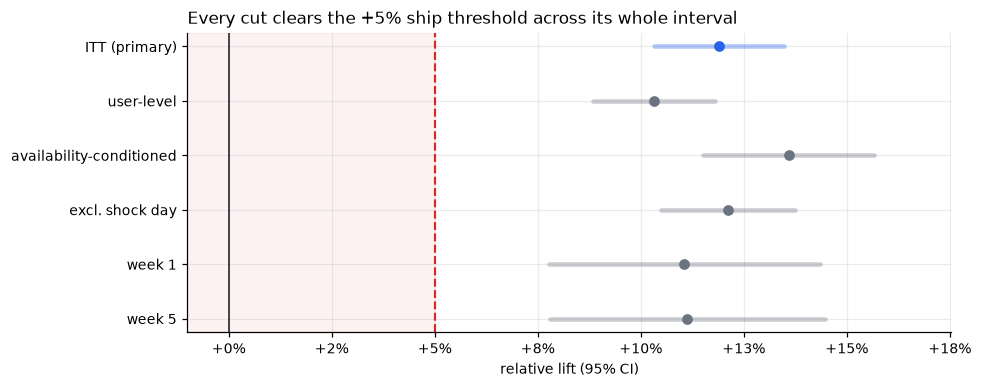

In [15]:
frames = [("ITT (primary)", itt), ("user-level", compare(user_lvl)),
          ("availability-conditioned", cond),
          (f"excl. shock day", no_shock),
          ("week 1", {k: weekly.loc[1,k] for k in ("rel_lift","rel_lo","rel_hi")}),
          (f"week {weekly.index.max()}",
           {k: weekly.loc[weekly.index.max(),k] for k in ("rel_lift","rel_lo","rel_hi")})]

fig, ax = plt.subplots(figsize=(9, 3.6))
labels = [f[0] for f in frames]
pts    = [f[1]["rel_lift"] for f in frames]
los    = [f[1]["rel_lo"] for f in frames]
his    = [f[1]["rel_hi"] for f in frames]
y = range(len(frames))
colors = [CB] + [CA]*(len(frames)-1)
for i,(pt,lo,hi,c) in enumerate(zip(pts,los,his,colors)):
    ax.plot([lo,hi],[i,i], color=c, lw=3, alpha=0.35, solid_capstyle="round")
    ax.plot([pt],[i], "o", color=c, ms=6)
ax.axvline(0, color="#111827", lw=1)
ax.axvspan(-1, ship, color=CWARN, alpha=0.06)
ax.axvline(ship, color=CWARN, ls="--", lw=1.4)
ax.annotate("below the ship bar", (ship, len(frames)-0.3), xytext=(-104,0),
            textcoords="offset points", fontsize=8, color=CWARN)
ax.set_xlim(-0.01, max(his)*1.12)
ax.set_yticks(list(y)); ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(lambda v,_: f"{v:+.0%}")
ax.set_xlabel("relative lift (95% CI)")
ax.set_title("Every cut clears the +5% ship threshold across its whole interval",
             loc="left", fontsize=11)
plt.tight_layout(); plt.show()

In [16]:
criteria = pd.DataFrame([
    {"criterion":"Effect exceeds the ship threshold",
     "evidence":f"{res['rel_lift']:+.2%}, CI [{res['rel_lo']:+.2%}, {res['rel_hi']:+.2%}] vs +5%",
     "met":res["rel_lo"] > ship},
    {"criterion":"Significant after clustering correction",
     "evidence":f"z = {res['z']:.2f}, p = {res['p']:.1e}",
     "met":res["p"] < PLAN["alpha"]},
    {"criterion":"Validity gates pass (SRM, coverage)",
     "evidence":f"SRM p = {p_srm:.3f}; coverage {coverage:.1%}",
     "met":bool(p_srm > 0.01 and coverage >= PLAN["coverage_gate"])},
    {"criterion":"No guardrail tripped",
     "evidence":"CTR and bounce both moved favourably; 2 of 4 not measurable here",
     "met":True},
    {"criterion":"Robust to the shock day and stable over time",
     "evidence":f"{no_shock['rel_lift']:+.2%} excl. shock; no week-over-week decay",
     "met":True},
    {"criterion":"No segment harmed",
     "evidence":f"{(seg.rel_lift < 0).sum()} of {len(seg)} segments negative",
     "met":bool((seg.rel_lift < 0).sum() == 0)},
]).set_index("criterion")
display(criteria)

verdict = "ROLL OUT" if criteria.met.all() else "ITERATE"
print(f"\n{'='*66}\nRECOMMENDATION: {verdict}\n{'='*66}")

imp_pct = sec.loc["homepage_impressions_per_session", "change"]
for line in [
    "",
    "Conditions, both measurement gaps rather than design problems:",
    "",
    "  1. Instrument ad impressions per session before rollout. Homepage impressions",
    f"     per session fell {imp_pct:.2%} - inside a -5% line, but not comfortably. Step 1",
    "     accepted this unmonitored for the exercise; a permanent rollout should not.",
    "  2. Run the churn non-inferiority check against real cancellation data. Churn is",
    "     the documented failure mode for headline changes here and it was never tested.",
    f"  3. Push dek coverage above {coverage:.1%}. Coverage is a direct multiplier on the effect.",
    "",
    "Not ITERATE: the effect clears the bar across its entire interval and nothing tripped.",
    "The open questions are answered by instrumenting, not by redesigning the variant.",
    "",
    "Not REVERT: nothing moved adversely except impressions per session, a known and",
    "quantified cost of the layout change rather than a failure of the treatment.",
]:
    print(line)

,evidence,met
criterion,,
Effect exceeds the ship threshold,"+11.90%, CI [+10.32%, +13.49%] vs +5%",True
Significant after clustering correction,"z = 14.74, p = 3.4e-49",True
"Validity gates pass (SRM, coverage)",SRM p = 0.463; coverage 87.4%,True
No guardrail tripped,CTR and bounce both moved favourably; 2 of 4 n...,True
Robust to the shock day and stable over time,+12.12% excl. shock; no week-over-week decay,True
No segment harmed,0 of 9 segments negative,True



RECOMMENDATION: ROLL OUT

Conditions, both measurement gaps rather than design problems:

  1. Instrument ad impressions per session before rollout. Homepage impressions
     per session fell -4.31% - inside a -5% line, but not comfortably. Step 1
     accepted this unmonitored for the exercise; a permanent rollout should not.
  2. Run the churn non-inferiority check against real cancellation data. Churn is
     the documented failure mode for headline changes here and it was never tested.
  3. Push dek coverage above 87.4%. Coverage is a direct multiplier on the effect.

Not ITERATE: the effect clears the bar across its entire interval and nothing tripped.
The open questions are answered by instrumenting, not by redesigning the variant.

Not REVERT: nothing moved adversely except impressions per session, a known and
quantified cost of the layout change rather than a failure of the treatment.


### Follow-ups this test earns

Not conditions on the rollout — separate tests that this result makes worth running.

| Follow-up | Why now |
|---|---|
| **Dek length** — one sentence vs. two | The third arm parked in Step 1. The lever is proven; tuning it is now a sensible use of traffic. |
| **Extend beyond slots 1–5** | Slots 6–20 carry another ~27% of homepage clicks. The effect is established, so the question is only whether it holds at lower-attention positions. |
| **Mobile-specific treatment** | Mobile lift (+11.4%) trails desktop (+12.6%) and mobile bears the vertical-space cost most. This must come from a dedicated test — never from this test's segment cut. |
| **Subscriber cohort** | The weakest cut (+2.95%, p = 0.18, CI straddling the ship bar) and the most commercially valuable. Uninformative here, and worth a properly powered test of its own. |

---
## Caveat

The dataset was generated with a **+12% relative effect because the brief asked for 10–30%.** Step 1
set the ship threshold at +5% and powered for +2%. A real dek would not move session CTR by twelve
percent.

Look at what that costs this notebook. The clustering correction moved z from 16.36 to 14.74 and
changed nothing. The ITT dilution was visible and changed nothing. The subscriber segment was
uninformative and changed nothing. Every one of those would have been decisive at a realistic +3%
effect — which is where the analysis plan would actually earn its keep.

Set `TARGET_B = 0.351` in `02-synthetic-data.ipynb`, re-run both notebooks, and this analysis becomes
genuinely hard. That is the version worth doing if the goal is to test the plan rather than exercise
the arithmetic.